In [ ]:
import os

dir_path = '/path/to/directory'

os.rmdir(dir_path)

In [1]:
import os
import cv2
import zipfile
import numpy as np
from glob import glob
from tqdm import tqdm
from skimage.feature import hog

zip_path = "/content/MIT-IB.zip"
extract_dir = "/content/MIT_IB"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

male_folder = os.path.join(extract_dir, 'male1')
female_folder = os.path.join(extract_dir, 'female')

male_count = len(glob(os.path.join(male_folder, '*')))
female_count = len(glob(os.path.join(female_folder, '*')))
print(f"Before augmentation: Male={male_count}, Female={female_count}")

def augment_image(img):
    augmented = []
    augmented.append(cv2.flip(img, 1))
    for angle in [-15, 15]:
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        rotated = cv2.warpAffine(img, M, (w, h))
        augmented.append(rotated)
    return augmented

images_needed = male_count - female_count
save_idx = female_count + 1
female_images = glob(os.path.join(female_folder, '*'))

while images_needed > 0:
    for img_path in tqdm(female_images, desc="Augmenting female images"):
        img = cv2.imread(img_path)
        augmented = augment_image(img)
        for aug in augmented:
            save_name = f"aug_{save_idx}.jpg"
            save_path = os.path.join(female_folder, save_name)
            cv2.imwrite(save_path, aug)
            save_idx += 1
            images_needed -= 1
            if images_needed <= 0:
                break
        if images_needed <= 0:
            break

enhanced_dir = "/content/MIT_IB_enhanced"
os.makedirs(enhanced_dir, exist_ok=True)
enh_male = os.path.join(enhanced_dir, "male1")
enh_female = os.path.join(enhanced_dir, "female")
os.makedirs(enh_male, exist_ok=True)
os.makedirs(enh_female, exist_ok=True)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def enhance_and_save(input_folder, output_folder):
    images = glob(os.path.join(input_folder, "*"))
    for path in tqdm(images, desc=f"Enhancing {os.path.basename(input_folder)}"):
        img = cv2.imread(path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        enhanced = clahe.apply(gray)
        enhanced_bgr = cv2.merge([enhanced, enhanced, enhanced])
        filename = os.path.basename(path)
        cv2.imwrite(os.path.join(output_folder, filename), enhanced_bgr)

enhance_and_save(male_folder, enh_male)
enhance_and_save(female_folder, enh_female)

print("✅ Enhancement done. Proceeding to HOG feature extraction...")

def extract_hog_features(folder, label):
    features = []
    labels = []
    image_paths = glob(os.path.join(folder, "*"))
    for path in tqdm(image_paths, desc=f"HOG: {os.path.basename(folder)}"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 128))
        feat = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), feature_vector=True)
        features.append(feat)
        labels.append(label)
    return features, labels

hog_male, label_male = extract_hog_features(enh_male, 0)
hog_female, label_female = extract_hog_features(enh_female, 1)

hog_features = np.array(hog_male + hog_female)
hog_labels = np.array(label_male + label_female)

print("✅ HOG Feature Extraction Completed")
print("Feature shape:", hog_features.shape)

Before augmentation: Male=600, Female=288


Enhancing female: 100%|██████████| 600/600 [00:00<00:00, 987.39it/s] 


✅ Enhancement done. Proceeding to HOG feature extraction...


HOG: female: 100%|██████████| 600/600 [00:03<00:00, 170.38it/s]

✅ HOG Feature Extraction Completed
Feature shape: (1200, 8100)


In [3]:
from skimage.feature import local_binary_pattern

def extract_lbp_features(folder, label, P=8, R=1):
    features = []
    labels = []
    image_paths = glob(os.path.join(folder, "*"))
    for path in tqdm(image_paths, desc=f"LBP: {os.path.basename(folder)}"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 128))
        lbp = local_binary_pattern(img, P, R, method="uniform")
        (hist, _) = np.histogram(lbp.ravel(),
                                 bins=np.arange(0, P + 3),
                                 range=(0, P + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)
        features.append(hist)
        labels.append(label)
    return features, labels

lbp_male, label_male_lbp = extract_lbp_features(enh_male, 0)
lbp_female, label_female_lbp = extract_lbp_features(enh_female, 1)

lbp_features = np.array(lbp_male + lbp_female)
lbp_labels = np.array(label_male_lbp + label_female_lbp)

print("✅ LBP Feature Extraction Completed")
print("Feature shape:", lbp_features.shape)

LBP: female: 100%|██████████| 600/600 [00:01<00:00, 373.89it/s]

✅ LBP Feature Extraction Completed
Feature shape: (1200, 10)


In [4]:
from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features(folder, label, distances=[1], angles=[0]):
    features = []
    labels = []
    image_paths = glob(os.path.join(folder, "*"))
    for path in tqdm(image_paths, desc=f"GLCM: {os.path.basename(folder)}"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 128))
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

        glcm = graycomatrix(img,
                            distances=distances,
                            angles=angles,
                            symmetric=True,
                            normed=True)

        contrast = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]

        features.append([contrast, homogeneity, energy, correlation])
        labels.append(label)
    return features, labels

glcm_male, label_male_glcm = extract_glcm_features(enh_male, 0)
glcm_female, label_female_glcm = extract_glcm_features(enh_female, 1)

glcm_features = np.array(glcm_male + glcm_female)
glcm_labels = np.array(label_male_glcm + label_female_glcm)

print("✅ GLCM Feature Extraction Completed")
print("Feature shape:", glcm_features.shape)

GLCM: female: 100%|██████████| 600/600 [00:01<00:00, 401.29it/s]

✅ GLCM Feature Extraction Completed
Feature shape: (1200, 4)


In [5]:
import tensorflow as tf
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img

base_model = VGG19(weights='imagenet', include_top=True)
fc7_model = Model(inputs=base_model.input, outputs=base_model.get_layer("fc2").output)

vgg_size = (224, 224)

def extract_vgg_features(folder, label):
    features = []
    labels = []
    image_paths = glob(os.path.join(folder, "*"))
    for path in tqdm(image_paths, desc=f"VGG19: {os.path.basename(folder)}"):
        img = load_img(path, target_size=vgg_size)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        feat = fc7_model.predict(img_array, verbose=0)
        features.append(feat.flatten())
        labels.append(label)
    return features, labels

vgg_male, vgg_male_labels = extract_vgg_features(enh_male, 0)
vgg_female, vgg_female_labels = extract_vgg_features(enh_female, 1)

vgg_features = np.array(vgg_male + vgg_female)
vgg_labels = np.array(vgg_male_labels + vgg_female_labels)

print("✅ VGG19 Feature Extraction Completed")
print("Feature shape:", vgg_features.shape)

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


VGG19: female: 100%|██████████| 600/600 [00:58<00:00, 10.22it/s]

✅ VGG19 Feature Extraction Completed
Feature shape: (1200, 4096)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

combined_features = np.concatenate([hog_features, lbp_features, glcm_features, vgg_features], axis=1)
print("✅ Features fused. Shape:", combined_features.shape)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(combined_features)

pca = PCA(n_components=0.95, random_state=42)
pca_features = pca.fit_transform(scaled_features)

print("✅ PCA Completed. Final shape:", pca_features.shape)


✅ Features fused. Shape: (1200, 12210)
✅ PCA Completed. Final shape: (1200, 872)


✅ Cross-Validation Results (10-fold):
Accuracy  : 0.7967
Precision : 0.8002
Recall    : 0.7933
F1-Score  : 0.7962


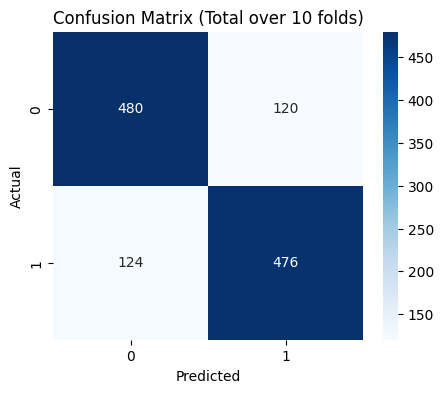

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accs, precs, recs, f1s = [], [], [], []
conf_matrix_total = np.array([[0, 0], [0, 0]])

for train_idx, test_idx in kf.split(pca_features, vgg_labels):
    X_train, X_test = pca_features[train_idx], pca_features[test_idx]
    y_train, y_test = vgg_labels[train_idx], vgg_labels[test_idx]

    clf = SVC(kernel='linear', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accs.append(accuracy_score(y_test, y_pred))
    precs.append(precision_score(y_test, y_pred))
    recs.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    conf_matrix_total += confusion_matrix(y_test, y_pred)

print("✅ Cross-Validation Results (10-fold):")
print(f"Accuracy  : {np.mean(accs):.4f}")
print(f"Precision : {np.mean(precs):.4f}")
print(f"Recall    : {np.mean(recs):.4f}")
print(f"F1-Score  : {np.mean(f1s):.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix_total, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Total over 10 folds)")
plt.show()

In [ ]:
from sklearn.svm import SVC

final_model = SVC(kernel='linear', random_state=42)
final_model.fit(pca_features, vgg_labels)


SVC(kernel='linear', random_state=42)

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def predict_image_gradio(image):
    img_resized = cv2.resize(image, (128, 128))

    hog_feat = hog(cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY),
                   pixels_per_cell=(8, 8), cells_per_block=(2, 2), feature_vector=True)

    lbp = local_binary_pattern(cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY), 8, 1, method="uniform")
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 8+3), range=(0, 8+2))
    lbp_hist = lbp_hist.astype("float") / (lbp_hist.sum() + 1e-6)

    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    vgg_img = cv2.resize(image, (224, 224))
    vgg_img = preprocess_input(np.expand_dims(vgg_img.astype("float32"), axis=0))
    deep_feat = fc7_model.predict(vgg_img, verbose=0).flatten()


    fused = np.concatenate([hog_feat, lbp_hist, [contrast, homogeneity, energy, correlation], deep_feat])

    fused_scaled = scaler.transform([fused])
    fused_pca = pca.transform(fused_scaled)

    pred = final_model.predict(fused_pca)[0]
    return "👨 Male" if pred == 0 else "👩 Female"

gr.Interface(
    fn=predict_image_gradio,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=gr.Text(label="Prediction"),
    title="Pedestrian Gender Classifier (HOG + LBP + GLCM + VGG19)",
    description="Upload an image of a person to predict gender using a hybrid classical + deep feature model."
).launch(debug=True)


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d4875b8c0340d92c71.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
